<a href="https://colab.research.google.com/github/vaalkate/ITMO_High_Performance_Graph_Analysis/blob/main/%D0%97%D0%B0%D0%B4%D0%B0%D1%87%D0%B0_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задача 2. Реализация подсчёта треугольников

Везде считаем, что вершины графа занумерованы подряд с нуля.

#### Пример для всех заданий

In [ ]:
!pip install python-graphblas

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import graphblas as gb
import pandas as pd


def draw_graphs_in_row(list_of_edges, titles):

    n = len(list_of_edges)

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))

    if n == 1:
        axes = [axes]

    for ax, edges, title in zip(axes, list_of_edges, titles):
        G = nx.Graph()
        G.add_edges_from(edges)

        pos = nx.spring_layout(G)

        nx.draw(
            G,
            pos,
            ax=ax,
            with_labels=True,
            node_color="lightblue",
            node_size=800,
            font_size=10,
            edge_color="gray"
        )

        ax.set_title(title)

    plt.tight_layout()
    plt.show()

In [ ]:
def build_adj_matrix(n, edges):
    rows = []
    cols = []

    for u, v in edges:
        rows.extend([u, v])
        cols.extend([v, u])

    values = [1] * len(rows)

    return gb.Matrix.from_coo(rows, cols, values,
                              nrows=n, ncols=n,
                              dtype=gb.dtypes.INT64)

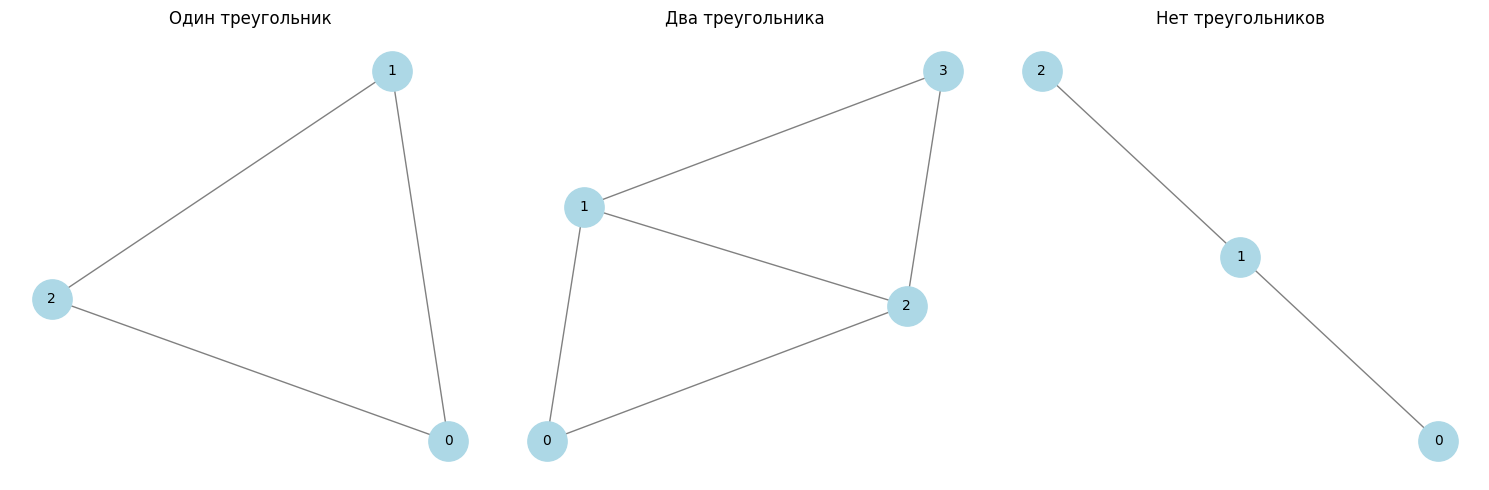

In [ ]:
# один треугольник
edges1 = [(0, 1), (1, 2), (2, 0)]
A1 = build_adj_matrix(3, edges1)

# два треугольника
edges2 = [(0, 1), (1, 2), (2, 0),
          (1, 3), (2, 3)]
A2 = build_adj_matrix(4, edges2)

# без треугольников
edges3 = [(0, 1), (1, 2)]
A3 = build_adj_matrix(3, edges3)


draw_graphs_in_row(
    [edges1, edges2, edges3],
    ["Один треугольник", "Два треугольника", "Нет треугольников"]
)

### Задание 1

Используя python-graphblas реализовать наивный алгоритм, для матрицы смежности $A$ вычисляющий $A^3$ и возвращающий количество треугольников неориентированного графа.
  - Функция принимает представление неориентированного графа, удобное для неё (загрузка, конвертация и проверка неориентированности реализованы отдельно).
  - Функция возвращает число --- количество треугольников в графе.

#### Решение задания 1

Пусть дан неориентированный граф с вершинами, занумерованными подряд с нуля (из условия): $ V = \{0, 1, \dots, n-1\} $

Матрица $A$  - матрица смежности неориентированного графа

Известно, что:

$$
\operatorname{trace}(A^3) = 6 \cdot T
$$

где: $T$ — число треугольников в графе.

Так как граф неориентированный, каждый треугольник (u, v, w) будет засчитан 6 раз (множитель 6 возникает т.к. каждый треугольник имеет 3 вершины в 2 направлениях обхода).

Поэтому общее количество треугольников вычисляется как сумма элементов главной диагонали матрицы $(A^3)$, делённая на 6:
$$
T = \frac{\operatorname{trace}(A^3)}{6}
$$


In [ ]:
import graphblas as gb

def count_triangles_naive(adj_matrix: gb.Matrix) -> int:
    """
    Наивный алгоритм подсчёта треугольников

    """

    # переводим в числовой тип
    A = adj_matrix.dup(dtype=gb.dtypes.INT64)

    # A^2
    A2 = A.mxm(A)

    # A^3
    A3 = A2.mxm(A)

    # извлечение диагонали матрицы A^3
    diag = A3.diag()

    # вычисление следа матрицы
    trace_obj = diag.reduce().value

    # если trace == None, значит сумма равна 0
    trace = trace_obj if trace_obj is not None else 0

    # каждый треугольник считается 6 раз
    triangles = trace // 6

    return triangles

In [ ]:
def build_adj_matrix(n, edges):
    rows = []
    cols = []

    for u, v in edges:
        rows.extend([u, v])
        cols.extend([v, u])

    values = [1] * len(rows)

    return gb.Matrix.from_coo(rows, cols, values,
                              nrows=n, ncols=n,
                              dtype=gb.dtypes.INT64)

Пример использования

In [ ]:
print("Треугольники (ожидаем 1):", count_triangles_naive(A1))
print("Треугольники (ожидаем 2):", count_triangles_naive(A2))
print("Треугольники (ожидаем 0):", count_triangles_naive(A3))

Треугольники (ожидаем 1): 1
Треугольники (ожидаем 2): 2
Треугольники (ожидаем 0): 0


### Задание 2 (алгоритм с маской)

Используя python-graphblas реализовать наивный алгоритм с маской, для матрицы смежности $A$ вычисляющий $A^2$ и возвращающий количество треугольников неориентированного графа.
 - Функция принимает представление неориентированного графа, удобное для неё (загрузка, конвертация и проверка неориентированности реализованы отдельно).
 - Функция возвращает число --- количество треугольников в графе.

#### Решение задания 2

Пусть дан неориентированный граф с вершинами, занумерованными подряд с нуля (из условия): $ V = \{0, 1, \dots, n-1\} $

Матрица $A$  - матрица смежности неориентированного графа.

Известно, что:

$$
(A^2)_{ij}
$$

равно числу путей длины 2 между вершинами $i$ и $j$.

Треугольник образуется, если одновременно:

- существует путь длины 2 между вершинами $i$ и $j$
- и существует ребро $(i,j)$

Поэтому используем маскирование:

$$
C = (A^2) \odot A
$$

где $\odot$ — поэлементное умножение (маска).

Сумма элементов полученной матрицы даёт вклад всех замкнутых путей длины 3.

Для неориентированного графа каждый треугольник учитывается 6 раз (3 вершины × 2 направления обхода), поэтому:

$$
T = \frac{\sum C_{ij}}{6}
$$

In [ ]:
import graphblas as gb
from graphblas import dtypes

def count_triangles_mask(A: gb.Matrix) -> int:
    """
    Наивный алгоритм подсчёта треугольников через A^2 и маскирование.

    """

    # приведение к числовому типу
    A = A.dup(dtype=dtypes.INT64)

    # вычисляем A^2
    A2 = A.mxm(A)

    # поэлементное умножение (маска)
    masked = A2.ewise_mult(A)

    # суммируем элементы
    total = masked.reduce_scalar(gb.agg.sum).value

    if total is None:
        total = 0

    # каждый треугольник учитывается 6 раз
    triangles = total // 6

    return triangles

In [ ]:
def build_adj_matrix(n, edges):
    rows = []
    cols = []

    for u, v in edges:
        rows.extend([u, v])
        cols.extend([v, u])

    values = [1] * len(rows)

    return gb.Matrix.from_coo(
        rows,
        cols,
        values,
        nrows=n,
        ncols=n,
        dtype=dtypes.INT64
    )

Пример использования

In [ ]:
print("Треугольники (ожидаем 1):", count_triangles_mask(A1))
print("Треугольники (ожидаем 2):", count_triangles_mask(A2))
print("Треугольники (ожидаем 0):", count_triangles_mask(A3))

Треугольники (ожидаем 1): 1
Треугольники (ожидаем 2): 2
Треугольники (ожидаем 0): 0


### Задание 3 (алгоритм Сohen)

Используя python-graphblas реализовать Сohen's algorithm, вычисляющий количество треугольников неориентированного графа.
 - Функция принимает представление неориентированного графа, удобное для неё (загрузка, конвертация и проверка неориентированности реализованы отдельно).
 - Функция возвращает число --- количество треугольников в графе.

#### Решение задания 3

Пусть дан неориентированный граф с вершинами, занумерованными подряд с нуля (из условия): $ V = \{0, 1, \dots, n-1\} $

Матрица $A$  - матрица смежности неориентированного графа

Алгоритм Cohen позволяет эффективно подсчитать количество треугольников, используя разложение матрицы смежности на верхнюю и нижнюю треугольные части.

Разобьём матрицу:

- $L$ — нижняя треугольная часть матрицы $A$
- $U$ — верхняя треугольная часть матрицы $A$

Тогда количество треугольников вычисляется следующим образом:

$$
T = \sum ( (L \cdot U) \odot A )
$$

где:

- $\cdot$ — матричное умножение
- $\odot$ — поэлементное умножение (маска)

Сумма берётся по всем элементам результата



In [ ]:
def count_triangles_cohen(A: gb.Matrix) -> int:
    """
    Реализация алгоритма Cohen для подсчёта треугольников.

    """

    # приведение к числовому типу
    A = A.dup(dtype=dtypes.INT64)

    # верхняя и нижняя треугольные части
    L = gb.select.tril(A)
    U = gb.select.triu(A)

    # матрица пересечения
    M = L.mxm(U)

    # маска по исходной матрице
    M = M.ewise_mult(A)

    # суммирование элементов
    total_obj = M.reduce_scalar(gb.agg.sum).value

    if total_obj is None:
        total = 0
    else:
        total = total_obj

    # в неориентированном графе каждый треугольник учитывается дважды
    return int(total // 2)

In [ ]:
def build_adj_matrix(n, edges):
    rows = []
    cols = []

    for u, v in edges:
        rows.extend([u, v])
        cols.extend([v, u])

    values = [1] * len(rows)

    return gb.Matrix.from_coo(
        rows,
        cols,
        values,
        nrows=n,
        ncols=n,
        dtype=dtypes.INT64
    )

Пример использования

In [ ]:
print("Треугольники (ожидаем 1):", count_triangles_cohen(A1))
print("Треугольники (ожидаем 2):", count_triangles_cohen(A2))
print("Треугольники (ожидаем 0):", count_triangles_cohen(A3))

Треугольники (ожидаем 1): 1
Треугольники (ожидаем 2): 2
Треугольники (ожидаем 0): 0


### Задание 4 (алгоритм Sandia)

Используя python-graphblas реализовать Sandia algorithm, вычисляющий количество треугольников неориентированного графа.
 - Функция принимает представление неориентированного графа, удобное для неё (загрузка, конвертация и проверка неориентированности реализованы отдельно).
 - Функция возвращает число --- количество треугольников в графе.

#### Решение задания 4

Пусть дан неориентированный граф с вершинами, занумерованными подряд с нуля (из условия): $ V = \{0, 1, \dots, n-1\} $

Матрица $A$  - матрица смежности неориентированного графа.

Sandia Algorithm — это оптимизированный алгоритм подсчёта треугольников, основанный на матричных операциях и использовании ориентированного обхода вершин.

Матрица смежности разбивается на верхнюю треугольную часть:

$$
U = \operatorname{triu}(A)
$$

Алгоритм вычисляет пересечение соседей для каждой пары вершин $(i,j)$, где $i < j$ и существует ребро $(i,j)$.

Количество треугольников вычисляется как сумма элементов результата:

$$
T = \sum ((U \cdot U^\top) \odot U)
$$

Для неориентированного графа каждый треугольник учитывается один раз, поэтому дополнительного деления не требуется.


In [ ]:
def count_triangles_sandia(A: gb.Matrix) -> int:
    """
    Реализация Sandia Algorithm для подсчёта треугольников.

    """

    # приведение к числовому типу
    A = A.dup(dtype=dtypes.INT64)

    # берём только верхнюю треугольную часть
    U = gb.select.triu(A)

    # пересечение соседей
    M = U.mxm(U.T)

    # маска по исходной матрице
    M = M.ewise_mult(U)

    # суммирование элементов
    total = M.reduce_scalar(gb.agg.sum).value

    if total is None:
        total = 0

    return int(total)

In [ ]:
def build_adj_matrix(n, edges):
    rows = []
    cols = []

    for u, v in edges:
        rows.extend([u, v])
        cols.extend([v, u])

    values = [1] * len(rows)

    return gb.Matrix.from_coo(
        rows,
        cols,
        values,
        nrows=n,
        ncols=n,
        dtype=dtypes.INT64
    )

Пример использования

In [ ]:
print("Треугольники (ожидаем 1):", count_triangles_sandia(A1))
print("Треугольники (ожидаем 2):", count_triangles_sandia(A2))
print("Треугольники (ожидаем 0):", count_triangles_sandia(A3))

Треугольники (ожидаем 1): 1
Треугольники (ожидаем 2): 2
Треугольники (ожидаем 0): 0


### Задание 5

(+2 балла) Используя python-graphblas реализовать функцию, вычисляющую для каждой вершины неориентированного графа количество треугольников, в которых она участвует.
 - Функция принимает представление неориентированного графа, удобное для неё (загрузка, конвертация и проверка неориентированности реализованы отдельно).
 - Функция возвращает массив, где для каждой вершины указано, в скольки треугольниках она участвует.

#### Решение задания 5

Пусть дан неориентированный граф с вершинами, занумерованными подряд с нуля (из условия): $ V = \{0, 1, \dots, n-1\} $

Матрица $A$  - матрица смежности неориентированного графа.


Известно, что:

$$
(A^2)_{ij}
$$

равно числу путей длины 2 между вершинами $i$ и $j$.

Если дополнительно существует ребро $(i,j)$, то каждая такая комбинация формирует треугольник.

Количество треугольников, в которых участвует вершина $i$, определяется как количество пар соседей вершины $i$, которые соединены между собой ребром.


Вычисляется:

$$
B = (A^2) \odot A
$$

где $\odot$ — поэлементное умножение (маска)

Тогда вклад вершины $i$ в треугольники равен сумме элементов строки $i$ полученной матрицы:

$$
t_i = \sum_j B_{ij}
$$

Таким образом, возвращается вектор:

$$
t_i = \sum_{j=0}^{n-1} (A^2)_{ij} \, A_{ij}
$$

где каждый элемент массива соответствует количеству треугольников, в которых участвует вершина.

In [ ]:
def triangles_per_vertex(A: gb.Matrix):
    """
    Возвращает массив, где для каждой вершины указано количество треугольников, в которых она участвует.

    """
    # приведение к числовому типу
    A = A.dup(dtype=dtypes.INT64)

    # вычисляем A^2
    T = A.mxm(A)

    # применяем маску исходной матрицы смежности
    T = T.ewise_mult(A)

    # cуммирование элементов
    T = T.reduce_rowwise(gb.agg.sum)

    result = T.to_dense(fill_value=0) // 2

    return result

In [ ]:
def build_adj_matrix(n, edges):
    rows = []
    cols = []

    for u, v in edges:
        rows.extend([u, v])
        cols.extend([v, u])

    values = [1] * len(rows)

    return gb.Matrix.from_coo(
        rows,
        cols,
        values,
        nrows=n,
        ncols=n,
        dtype=dtypes.INT64
    )

Пример использования

In [ ]:
print("Треугольники на вершину (1 треугольник):")
print(triangles_per_vertex(A1))
print("\nТреугольники на вершину (2 треугольника):")
print(triangles_per_vertex(A2))
print("\nТреугольники на вершину (нет треугольников):")
print(triangles_per_vertex(A3))

Треугольники на вершину (1 треугольник):
[1 1 1]

Треугольники на вершину (2 треугольника):
[1 2 2 1]

Треугольники на вершину (нет треугольников):
[0 0 0]


### Задание 6

(+1 балл) Скачать 10 графов в формате Matrix Market с сайта SuiteSparse Matrix Collection и оценить время работы всех полученных реализаций. Сделать выводы.
 В качестве фильтров для поиска графов на сайте использовать следующие значения: Rutherford-Boeing Type = Binary, Special Structure = Symmetric, Nonzeros.Min = 10000.

#### Решение задания 6

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import glob
import os

folder_path = "/content/drive/MyDrive/Colab Notebooks/Графы/Matrix Market"

mtx_files = glob.glob(folder_path + "/*.mtx")

graphs = []

for file in mtx_files:
    print("Загрузка:", file)
    A = gb.io.mmread(file)

    filename = os.path.basename(file)

    graphs.append((filename, A))

Загрузка: /content/drive/MyDrive/Colab Notebooks/Графы/Matrix Market/bcspwr10.mtx
Загрузка: /content/drive/MyDrive/Colab Notebooks/Графы/Matrix Market/bcsstk29.mtx
Загрузка: /content/drive/MyDrive/Colab Notebooks/Графы/Matrix Market/bcsstk32.mtx
Загрузка: /content/drive/MyDrive/Colab Notebooks/Графы/Matrix Market/bcsstk33.mtx
Загрузка: /content/drive/MyDrive/Colab Notebooks/Графы/Matrix Market/can_838.mtx
Загрузка: /content/drive/MyDrive/Colab Notebooks/Графы/Matrix Market/dwt_992.mtx
Загрузка: /content/drive/MyDrive/Colab Notebooks/Графы/Matrix Market/eris1176.mtx
Загрузка: /content/drive/MyDrive/Colab Notebooks/Графы/Matrix Market/lshp2233.mtx
Загрузка: /content/drive/MyDrive/Colab Notebooks/Графы/Matrix Market/lshp3025.mtx
Загрузка: /content/drive/MyDrive/Colab Notebooks/Графы/Matrix Market/lshp3466.mtx


In [ ]:
print(len(graphs))

10


In [ ]:
algorithms = {
    "Naive": count_triangles_naive,
    "Mask": count_triangles_mask,
    "Cohen": count_triangles_cohen,
    "Sandia": count_triangles_sandia,
    "PerVertex": triangles_per_vertex
}

In [ ]:
import time
import pandas as pdвкф

results = []

for name, A in graphs:

    row = {"Graph": name}

    for alg_name, alg_func in algorithms.items():

        times = []

        for _ in range(3):  # усредняем
            start = time.time()
            alg_func(A)
            times.append(time.time() - start)

        row[alg_name] = sum(times) / len(times)

    results.append(row)


df = pd.DataFrame(results)
df

,Graph,Naive,Mask,Cohen,Sandia,PerVertex
0,bcspwr10.mtx,0.029314,0.009778,0.003653,0.004601,0.006875
1,bcsstk29.mtx,1.097134,0.504944,0.307289,0.331651,0.462629
2,bcsstk32.mtx,3.175406,0.817464,0.378115,0.431493,1.315241
3,bcsstk33.mtx,1.150784,0.213777,0.070740,0.076228,0.207641
4,can_838.mtx,0.006534,0.002839,0.002736,0.001261,0.002822
5,dwt_992.mtx,0.005425,0.002678,0.002269,0.002057,0.002839
6,eris1176.mtx,0.009960,0.004110,0.002988,0.002470,0.004068
7,lshp2233.mtx,0.006260,0.004522,0.001786,0.001536,0.002528
8,lshp3025.mtx,0.007011,0.002889,0.002105,0.001889,0.002997
9,lshp3466.mtx,0.007772,0.003394,0.002376,0.002232,0.003269


#### Выводы по заданию 6

1. **Наивный алгоритм (Naive)**
   На всех графах показывает наибольшее время выполнения.  
   Особенно заметно замедление на графах большего размера (например, bcsstk29.mtx, bcsstk32.mtx).  
   Это ожидаемо, так как алгоритм выполняет полное матричное умножение без оптимизаций.

2. **Алгоритм с маской (Mask)**
   Работает значительно быстрее наивного варианта.  
   Улучшение связано с тем, что вычисления ограничиваются существующими рёбрами графа,
   что уменьшает количество операций.

3. **Алгоритм Cohen**
   Показывает более стабильные и обычно более быстрые результаты по сравнению с Mask.  
   Эффективность достигается за счёт ограничения вычислений верхней треугольной частью матрицы,
   что уменьшает объём обрабатываемых данных.

4. **Алгоритм Sandia**
   Часто демонстрирует лучшие результаты по времени на большинстве графов.  
   Это связано с дополнительной оптимизацией и более узким пространством вычислений.

5. **Per-Vertex вычисление**
   По времени находится между Mask и Cohen.  
   Алгоритм выполняет дополнительные операции по суммированию строк,
   что влияет на производительность.


Все оптимизированные алгоритмы (Mask, Cohen, Sandia) работают значительно быстрее наивного метода. Разница во времени становится более заметной на графах большего размера. Sandia и Cohen показывают наилучшую производительность среди рассмотренных реализаций.


### Задание 7

(+2 балла) Реализовать генератор случайных неориентированных графов, в котором можно задавать количество вершин и степень разреженности графа. Путём генерации случайных графов различного размера и с разной степенью разреженности, оценить время работы всех полученных реализаций и исследовать границы их применимости. Сделать выводы.

#### Решение задания 7

In [ ]:
import numpy as np

def generate_random_graph(n, density=0.1):
    """
    Генерация случайного неориентированного графа

    n — количество вершин
    density — вероятность появления ребра (0 < density <= 1)
    """

    rows = []
    cols = []

    for i in range(n):
        for j in range(i + 1, n):
            if np.random.rand() < density:
                rows.extend([i, j])
                cols.extend([j, i])

    values = [1] * len(rows)

    A = gb.Matrix.from_coo(
        rows,
        cols,
        values,
        nrows=n,
        ncols=n,
        dtype=gb.dtypes.INT64
    )

    return A

In [ ]:
algorithms = {
    "Naive": count_triangles_naive,
    "Mask": count_triangles_mask,
    "Cohen": count_triangles_cohen,
    "Sandia": count_triangles_sandia,
    "PerVertex": triangles_per_vertex
}

In [ ]:
def benchmark_all(n_values, densities, repeats=3):
    """
    Генерирует графы разного размера и плотности,
    измеряет время всех алгоритмов
    """

    results = []

    for n in n_values:
        for density in densities:
            A = generate_random_graph(n, density)
            row = {"n": n, "density": density}

            for alg_name, alg_func in algorithms.items():
                times = []
                for _ in range(repeats):
                    start = time.time()
                    alg_func(A)
                    times.append(time.time() - start)
                row[alg_name] = np.mean(times)
            results.append(row)

    return pd.DataFrame(results)

In [ ]:
n_values = [100, 300, 500, 1000, 2000, 5000]
densities = [0.01, 0.05, 0.1]

In [ ]:
df = benchmark_all(n_values, densities)
df

,n,density,Naive,Mask,Cohen,Sandia,PerVertex
0,100,0.01,0.000636,0.000376,0.000521,0.000338,0.000443
1,100,0.05,0.000837,0.000340,0.000441,0.000417,0.000538
2,100,0.10,0.001016,0.000503,0.000814,0.000432,0.000640
3,300,0.01,0.000895,0.000452,0.000460,0.000387,0.000610
4,300,0.05,0.007512,0.002264,0.001482,0.001262,0.002377
5,300,0.10,0.006871,0.002713,0.002428,0.002665,0.003360
6,500,0.01,0.002740,0.000888,0.000692,0.000582,0.001064
7,500,0.05,0.014042,0.004694,0.003914,0.003556,0.004745
8,500,0.10,0.025047,0.007591,0.005159,0.005329,0.007622
9,1000,0.01,0.033583,0.005684,0.003839,0.003180,0.007123


#### Выводы по заданию 7


**1. Влияние размера графа (n)**

Из таблицы видно, что при увеличении количества вершин:

- Время работы всех алгоритмов растёт.
- Рост особенно заметен для наивного алгоритма.
- При n ≥ 2000 наивный алгоритм становится существенно медленнее остальных.

Это подтверждает теоретическую сложность метода через вычисление $( A^3 $),
которая плохо масштабируется.

**2. Влияние разреженности (density)**

При фиксированном n увеличение density приводит к:

- Росту времени выполнения всех алгоритмов.
- Существенному замедлению наивного метода.
- Менее выраженному росту у алгоритмов с использованием разреженной структуры (Mask, Cohen, Sandia).

Чем плотнее граф, тем меньше преимуществ даёт разреженное представление,
и разница между алгоритмами уменьшается.

**3. Сравнение алгоритмов**

По результатам эксперимента можно сделать следующие выводы:

- **Naive** — работает значительно медленнее всех остальных, особенно при больших n и высокой плотности. Применим только для маленьких графов (n ≤ 500).
- **Mask** — показывает существенное ускорение по сравнению с Naive. Подходит для средних и больших разреженных графов.
- **Cohen** — стабильно быстрее Mask на больших графах. Подходит для средних и больших разреженных графов.
- **Sandia** — чаще всего демонстрирует лучшие результаты среди матричных алгоритмов. Обеспечивает наилучшую производительность на крупных разреженных графах по сравнению с другими реализациями.
- **PerVertex** — имеет промежуточную производительность, но уступает Cohen и Sandia на крупных графах.


Оптимизированные алгоритмы демонстрируют значительное ускорение по сравнению с наивной реализацией, особенно при увеличении размера графа.